In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import os

os.listdir('/kaggle/input/creditcardfraud')

['creditcard.csv']

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


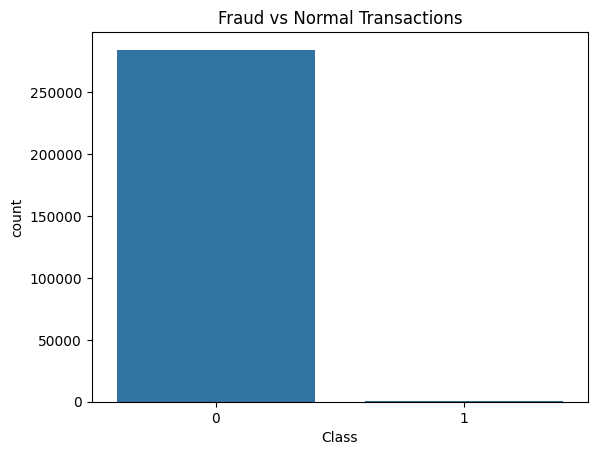

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

In [8]:
df = df.drop('Time', axis=1)

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
!pip install imbalanced-learn

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[56688   176]
 [   12    86]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9738651404568581


In [20]:
y_pred_custom = (y_prob > 0.7).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.87      0.64        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print(importance.head(10))

V14    0.547353
V4     0.047082
V8     0.037333
V12    0.035609
V13    0.022767
V10    0.018203
V26    0.018069
V18    0.017113
V17    0.015963
V1     0.015570
dtype: float32


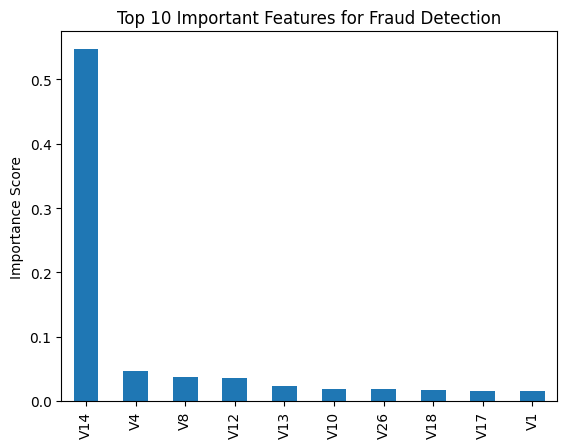

In [22]:
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features for Fraud Detection")
plt.ylabel("Importance Score")
plt.show()

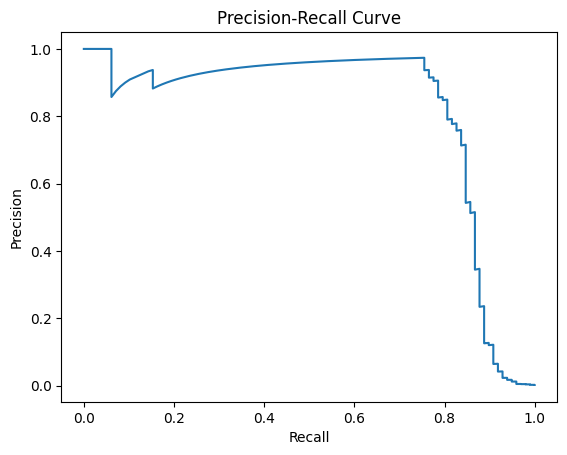

In [23]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

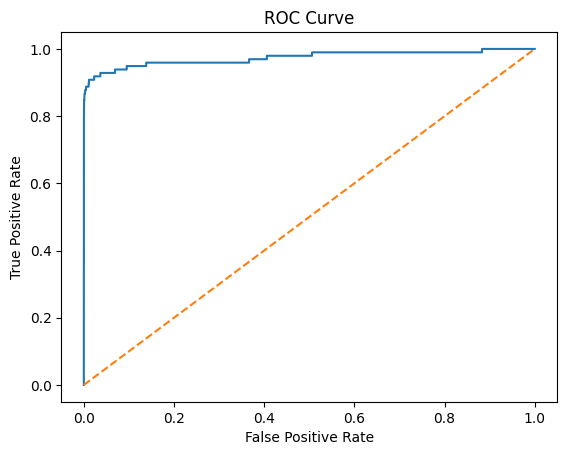

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

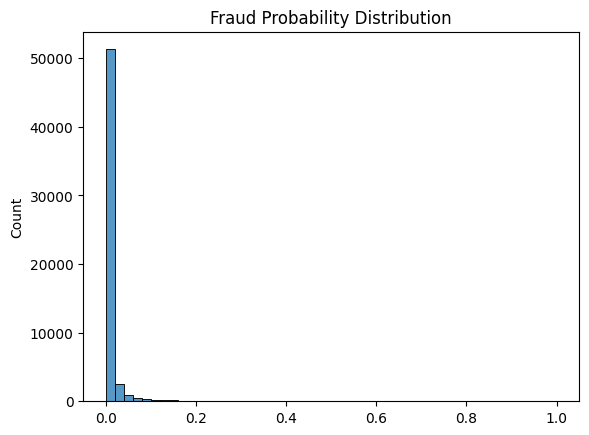

In [25]:
import seaborn as sns

sns.histplot(y_prob, bins=50)
plt.title("Fraud Probability Distribution")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced")

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [28]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

In [29]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

In [30]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

In [31]:
y_pred_xgb = model.predict(X_test)
y_prob_xgb = model.predict_proba(X_test)[:,1]

xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

In [32]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Recall": [lr_recall, rf_recall, xgb_recall],
    "Precision": [lr_precision, rf_precision, xgb_precision],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc]
})

results

,Model,Recall,Precision,ROC-AUC
0,Logistic Regression,0.642857,0.828947,0.955973
1,Random Forest,0.755102,0.948718,0.947830
2,XGBoost,0.877551,0.328244,0.973865


In [33]:
results = results.round(3)
results

,Model,Recall,Precision,ROC-AUC
0,Logistic Regression,0.643,0.829,0.956
1,Random Forest,0.755,0.949,0.948
2,XGBoost,0.878,0.328,0.974


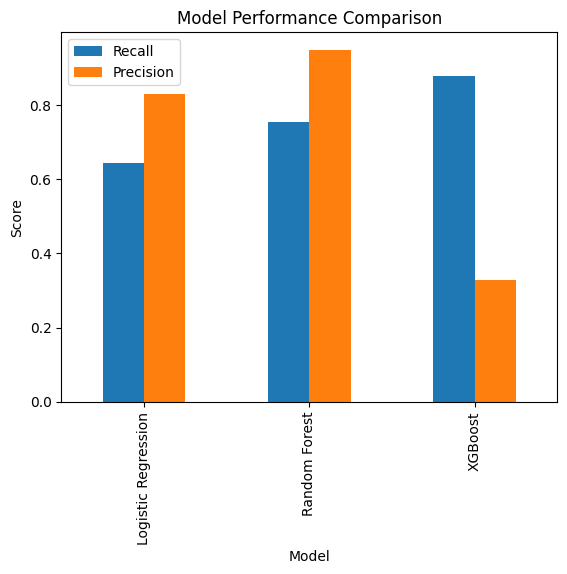

In [34]:
results.set_index("Model")[["Recall","Precision"]].plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [35]:
!pip install shap

In [36]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:1000])

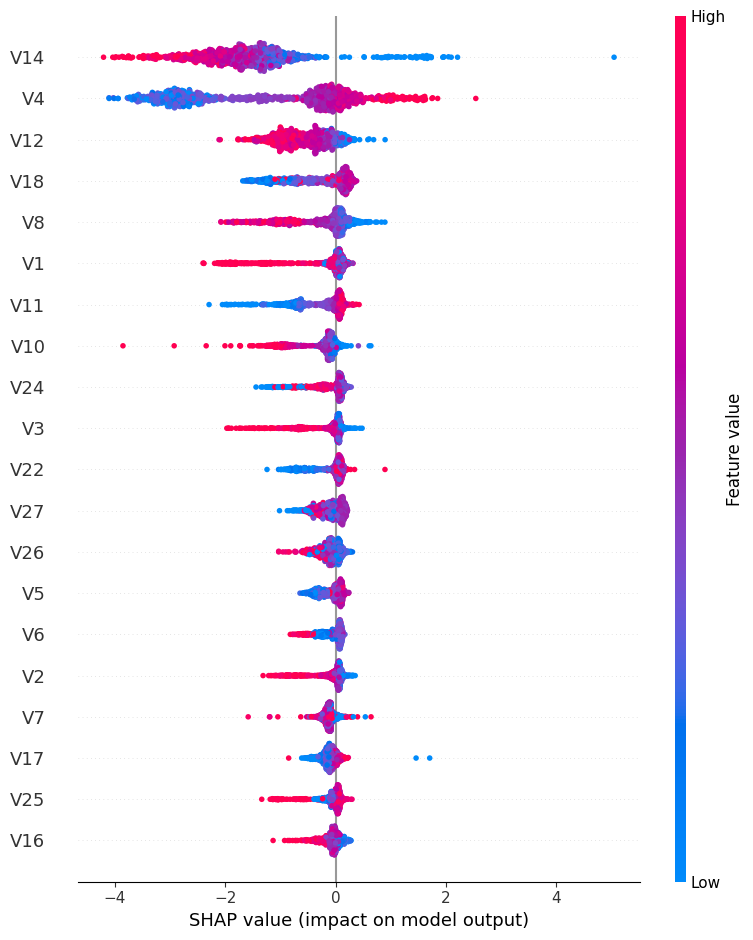

In [37]:
shap.summary_plot(shap_values, X_test[:1000])